# Stage 2: Meta-Learning Experiment Controller

This notebook is the interactive controller for Stage 2. It resolves Stage 2 experiments
from the central YAML configuration, optionally applies notebook-level overrides, previews
the resulting experiment list, optionally runs the selected experiments, and then loads
the saved registry for quick inspection.

Full comparative analysis belongs in `17.1_stage2_analysis_dashboard.ipynb`.


In [1]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import pandas as pd

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_PATH = PROJECT_ROOT / "src"
EXPERIMENTS_PATH = PROJECT_ROOT / "experiments"

for _p in [str(SRC_PATH), str(PROJECT_ROOT)]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

from master_thesis.stage2 import (
    load_stage2_config,
    resolve_experiment_grid,
    build_experiment_preview_df,
)
from master_thesis.plotting import set_thesis_style, plot_stage2_metric_comparison

set_thesis_style(palette="dtu", font_scale=1.05, grid=False)


{'zero_shot': '#DADADA',
 'zero-shot': '#DADADA',
 'pretrained': '#030F4F',
 'finetune': '#2F3EEA',
 'fine_tune': '#2F3EEA',
 'fine-tune': '#2F3EEA',
 'anil': '#1FD082',
 'fomaml': '#FC7634',
 'maml': '#990000',
 'xgboost': '#CC79A7',
 'elastic_net': '#56B4E9',
 'elastic net': '#56B4E9',
 'mean_predictor': '#999999',
 'mean predictor': '#999999'}

## Notebook-Level Experiment Controls

Edit the cell below to configure which experiments to run or preview.
All settings in this cell flow through the shared backend and produce the same
experiment IDs and artifact structure as the CLI runner.

---

### Recommended: Fair 4-method comparison (START HERE)

Run all four methods with **identical** settings so results are directly comparable:

```python
# Step 1 — sanity-check the pipeline (~2 min):
PRESET = "four_method_quick"
RUN_EXPERIMENTS = True

# Step 2 — full evaluation when the pipeline looks correct:
PRESET = "four_method_benchmark"
RUN_EXPERIMENTS = True
```

This produces exactly **4 experiments**, one per method (finetune / ANIL / FOMAML / MAML),
all using the same init (`A_weak_only`), support size (5+5), and inner steps (5).
After running, open `17.1_stage2_analysis_dashboard.ipynb` to compare results.

---

### Other common patterns

```python
# Full thesis grid — 48 experiments (4 methods × 3 support × 2 steps × 2 inits):
PRESET = "thesis_main"

# Force-rerun a previously completed experiment:
FORCE_RERUN = True

# Override specific grid dimensions without changing the preset:
PRESET = "four_method_benchmark"
SUPPORT_GRID_OVERRIDE = [{"n_support_pos": 10, "n_support_neg": 10}]
INNER_STEPS_OVERRIDE = [1, 3, 5]

# Use a different Stage 1 initialisation:
INIT_NAMES_OVERRIDE = ["C_hybrid"]
```


In [2]:
CONFIG_PATH = PROJECT_ROOT / "experiments" / "stage2_config.yaml"

# --- Preset selection ---
# Options:
#   "four_method_benchmark"  — 4 methods × same settings, full evaluation  ← START HERE
#   "four_method_quick"      — same as above but minimal iterations (~2 min), for pipeline testing
#   "thesis_main"            — full grid: 4 methods × 3 support × 2 inner_steps × 2 inits (48 expts)
#   "quick_debug"            — 2 methods, minimal settings
#   "imbalance_debug"        — imbalanced support sizes
PRESET = "four_method_benchmark"

# --- Execution flags ---
# Set RUN_EXPERIMENTS = True to execute the resolved experiments.
RUN_EXPERIMENTS = True  
FORCE_RERUN = True

# --- Optional grid overrides (set to None to inherit from the preset) ---
# METHODS_OVERRIDE: list of method names, e.g. ["anil", "finetune"]
METHODS_OVERRIDE = None
# SUPPORT_GRID_OVERRIDE: list of dicts, e.g. [{"n_support_pos": 5, "n_support_neg": 5}]
SUPPORT_GRID_OVERRIDE = None
# INNER_STEPS_OVERRIDE: list of int, e.g. [1, 3, 5]
INNER_STEPS_OVERRIDE = None
# INIT_NAMES_OVERRIDE: list of init names, e.g. ["A_weak_only", "C_hybrid"]
INIT_NAMES_OVERRIDE = None
# TARGET_DEPARTMENTS_OVERRIDE: list of dept names, e.g. ["Logistics"]
TARGET_DEPARTMENTS_OVERRIDE = None
# PRESET_META_OVERRIDES: dict of meta-config overrides, e.g. {"meta_iterations": 10, "n_repeats": 3}
PRESET_META_OVERRIDES = None


## Resolve Experiment Specification


In [3]:
full_config = load_stage2_config(CONFIG_PATH)

override_payload = {}
if METHODS_OVERRIDE is not None:
    override_payload["methods"] = METHODS_OVERRIDE
if SUPPORT_GRID_OVERRIDE is not None:
    override_payload["support_grid"] = SUPPORT_GRID_OVERRIDE
if INNER_STEPS_OVERRIDE is not None:
    override_payload["inner_steps_grid"] = INNER_STEPS_OVERRIDE
if INIT_NAMES_OVERRIDE is not None:
    override_payload["init_names"] = INIT_NAMES_OVERRIDE
if TARGET_DEPARTMENTS_OVERRIDE is not None:
    override_payload["target_departments"] = TARGET_DEPARTMENTS_OVERRIDE
if PRESET_META_OVERRIDES is not None:
    override_payload.update(PRESET_META_OVERRIDES)

experiment_list = resolve_experiment_grid(
    full_config=full_config,
    preset_name=PRESET,
    overrides=override_payload,
)

preview_df = build_experiment_preview_df(experiment_list)
exp_ids = [exp_id for exp_id, _ in experiment_list]

print("Selected preset:", PRESET)
print("Run experiments:", RUN_EXPERIMENTS)
print("Force rerun:", FORCE_RERUN)
print("Resolved experiments:", len(preview_df))
display(preview_df)


Selected preset: four_method_benchmark
Run experiments: True
Force rerun: True
Resolved experiments: 4


,experiment_id,method,n_support_pos,n_support_neg,inner_steps,init_name,target_department,data_filename
0,stage2__init-A_weak_only__method-finetune__kpo...,finetune,5,5,5,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv
1,stage2__init-A_weak_only__method-anil__kpos-5_...,anil,5,5,5,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv
2,stage2__init-A_weak_only__method-fomaml__kpos-...,fomaml,5,5,5,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv
3,stage2__init-A_weak_only__method-maml__kpos-5_...,maml,5,5,5,A_weak_only,Logistics,contract_with_features_labeled_with_gold.csv


## Diagnostics


In [4]:
if len(experiment_list) == 0:
    raise ValueError("Resolved experiment list is empty.")

first_experiment_id, first_config = experiment_list[0]
data_filename = first_config["data"]["data_filename"]
data_path = PROJECT_ROOT / "Data" / "processed" / data_filename

print("First experiment ID:", first_experiment_id)
print("Stage 2 data file:", data_path)
print("Target department:", first_config["task_config"]["target_department"])
print("Stage 1 initialization:", first_config["stage1_init"]["init_name"])

if not data_path.exists():
    raise FileNotFoundError(f"Stage 2 data file not found: {data_path}")

df_stage2 = pd.read_csv(data_path, low_memory=False)
print("Dataset shape:", df_stage2.shape)
print("Has gold_y:", "gold_y" in df_stage2.columns)
print("Has renegotiation_prob:", "renegotiation_prob" in df_stage2.columns)


First experiment ID: stage2__init-A_weak_only__method-finetune__kpos-5__kneg-5__steps-5__target-Logistics
Stage 2 data file: /Users/Thomas/Desktop/Master Thesis/Data/processed/contract_with_features_labeled_with_gold.csv
Target department: Logistics
Stage 1 initialization: A_weak_only
Dataset shape: (9201, 168)
Has gold_y: True
Has renegotiation_prob: True


## Optional Execution

Set `RUN_EXPERIMENTS = True` in the controls cell above to run the resolved experiments.
Results are saved to `models/stage_2/experiments/<experiment_id>/` and indexed in
`models/stage_2/experiments/experiment_summary.csv`.


In [5]:
if RUN_EXPERIMENTS:
    import importlib.util
    _spec = importlib.util.spec_from_file_location(
        "run_stage2", EXPERIMENTS_PATH / "run_stage2.py"
    )
    _run_stage2_mod = importlib.util.module_from_spec(_spec)
    _spec.loader.exec_module(_run_stage2_mod)
    run_experiments = _run_stage2_mod.run_experiments

    results = run_experiments(
        experiment_list=experiment_list,
        skip_if_exists=not FORCE_RERUN,
        force_rerun=FORCE_RERUN,
        verbose=True,
    )
    print(f"Completed {len(results)} experiment rows.")
else:
    print("Execution skipped. Set RUN_EXPERIMENTS = True to run the resolved experiments.")


Running experiment: stage2__init-A_weak_only__method-finetune__kpos-5__kneg-5__steps-5__target-Logistics
Stage 2 task table created
Rows: 533
Unique contracts: 94
Departments: 14
Positive labels: 353
Negative labels: 180
Department task summary created
Departments: 14
Total labeled rows: 533
Total positive rows: 353
Total negative rows: 180
Total labeled contracts: 94
Total positive contracts: 45
Total negative contracts: 49
Department task summary created
Departments: 14
Total labeled rows: 533
Total positive rows: 353
Total negative rows: 180
Total labeled contracts: 94
Total positive contracts: 45
Total negative contracts: 49
Department validity filtering completed
Valid departments: 2
Invalid departments: 12
Running experiment: stage2__init-A_weak_only__method-anil__kpos-5__kneg-5__steps-5__target-Logistics
Stage 2 task table created
Rows: 533
Unique contracts: 94
Departments: 14
Positive labels: 353
Negative labels: 180
Department task summary created
Departments: 14
Total labeled

## Backfill Legacy Results

This cell detects any Stage 2 experiment results that were saved in the legacy
directory structure (`models/stage_2/{init_name}/{method}/`) and migrates them
into the grid-based `experiments/` registry used by this notebook and notebook 17.1.

Run this cell once after any run that used the old-style pipeline.
It is safe to run multiple times — already-registered experiments are skipped.


In [6]:
from master_thesis.stage2 import backfill_legacy_stage2_results

backfill_summary = backfill_legacy_stage2_results(verbose=True)

if not backfill_summary.empty:
    print(f"Registry now contains {len(backfill_summary)} experiment(s).")
    _method_counts = backfill_summary['method'].value_counts() if 'method' in backfill_summary.columns else {}
    print('Methods in registry:', _method_counts.to_dict())


Backfilled: stage2__init-A_weak_only__method-anil__kpos-2__kneg-2__steps-5__target-Logistics
Backfilled: stage2__init-A_weak_only__method-maml__kpos-2__kneg-2__steps-5__target-Logistics
Backfilled: stage2__init-A_weak_only__method-finetune__kpos-2__kneg-2__steps-5__target-Logistics
Backfilled: stage2__init-A_weak_only__method-fomaml__kpos-2__kneg-2__steps-5__target-Logistics
Added 4 legacy experiment(s) to registry.
Saved updated experiment_summary.csv to /Users/Thomas/Desktop/Master Thesis/models/stage_2/experiments/experiment_summary.csv
Registry now contains 8 experiment(s).
Methods in registry: {'anil': 2, 'finetune': 2, 'fomaml': 2, 'maml': 2}


## Load Experiment Registry


In [7]:
EXPERIMENT_ROOT = PROJECT_ROOT / "models" / "stage_2" / "experiments"
SUMMARY_PATH = EXPERIMENT_ROOT / "experiment_summary.csv"

if SUMMARY_PATH.exists():
    experiment_summary = pd.read_csv(SUMMARY_PATH)
    print("Loaded experiment summary:", SUMMARY_PATH)
    print("Rows:", len(experiment_summary))
    display(experiment_summary.head(20))
else:
    print("No experiment summary file found yet at:", SUMMARY_PATH)
    experiment_summary = pd.DataFrame()


Loaded experiment summary: /Users/Thomas/Desktop/Master Thesis/models/stage_2/experiments/experiment_summary.csv
Rows: 8


,experiment_id,method,init_name,target_department,n_support_pos,n_support_neg,inner_steps,status,n_metric_rows,n_predictions,...,recall_at_10_mean,recall_at_10_std,ndcg_at_10_mean,ndcg_at_10_std,precision_at_20_mean,precision_at_20_std,recall_at_20_mean,recall_at_20_std,ndcg_at_20_mean,ndcg_at_20_std
0,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,A_weak_only,Logistics,2,2,5,success,20,205,...,0.906623,0.126552,0.898369,0.087197,0.744766,0.130334,1.0,0.0,0.950785,0.036881
1,stage2__init-A_weak_only__method-anil__kpos-5_...,anil,A_weak_only,Logistics,5,5,5,success,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,stage2__init-A_weak_only__method-finetune__kpo...,finetune,A_weak_only,Logistics,2,2,5,success,20,205,...,0.912835,0.127617,0.849515,0.076135,0.744766,0.130334,1.0,0.0,0.891858,0.061573
3,stage2__init-A_weak_only__method-finetune__kpo...,finetune,A_weak_only,Logistics,5,5,5,no_target_episodes_available,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,stage2__init-A_weak_only__method-fomaml__kpos-...,fomaml,A_weak_only,Logistics,2,2,5,success,20,205,...,0.920909,0.119990,0.896894,0.072946,0.744766,0.130334,1.0,0.0,0.941844,0.059382
5,stage2__init-A_weak_only__method-fomaml__kpos-...,fomaml,A_weak_only,Logistics,5,5,5,success,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,stage2__init-A_weak_only__method-maml__kpos-2_...,maml,A_weak_only,Logistics,2,2,5,success,20,205,...,0.931169,0.112947,0.866941,0.123312,0.744766,0.130334,1.0,0.0,0.912426,0.105749
7,stage2__init-A_weak_only__method-maml__kpos-5_...,maml,A_weak_only,Logistics,5,5,5,success,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Quick Comparison Preview


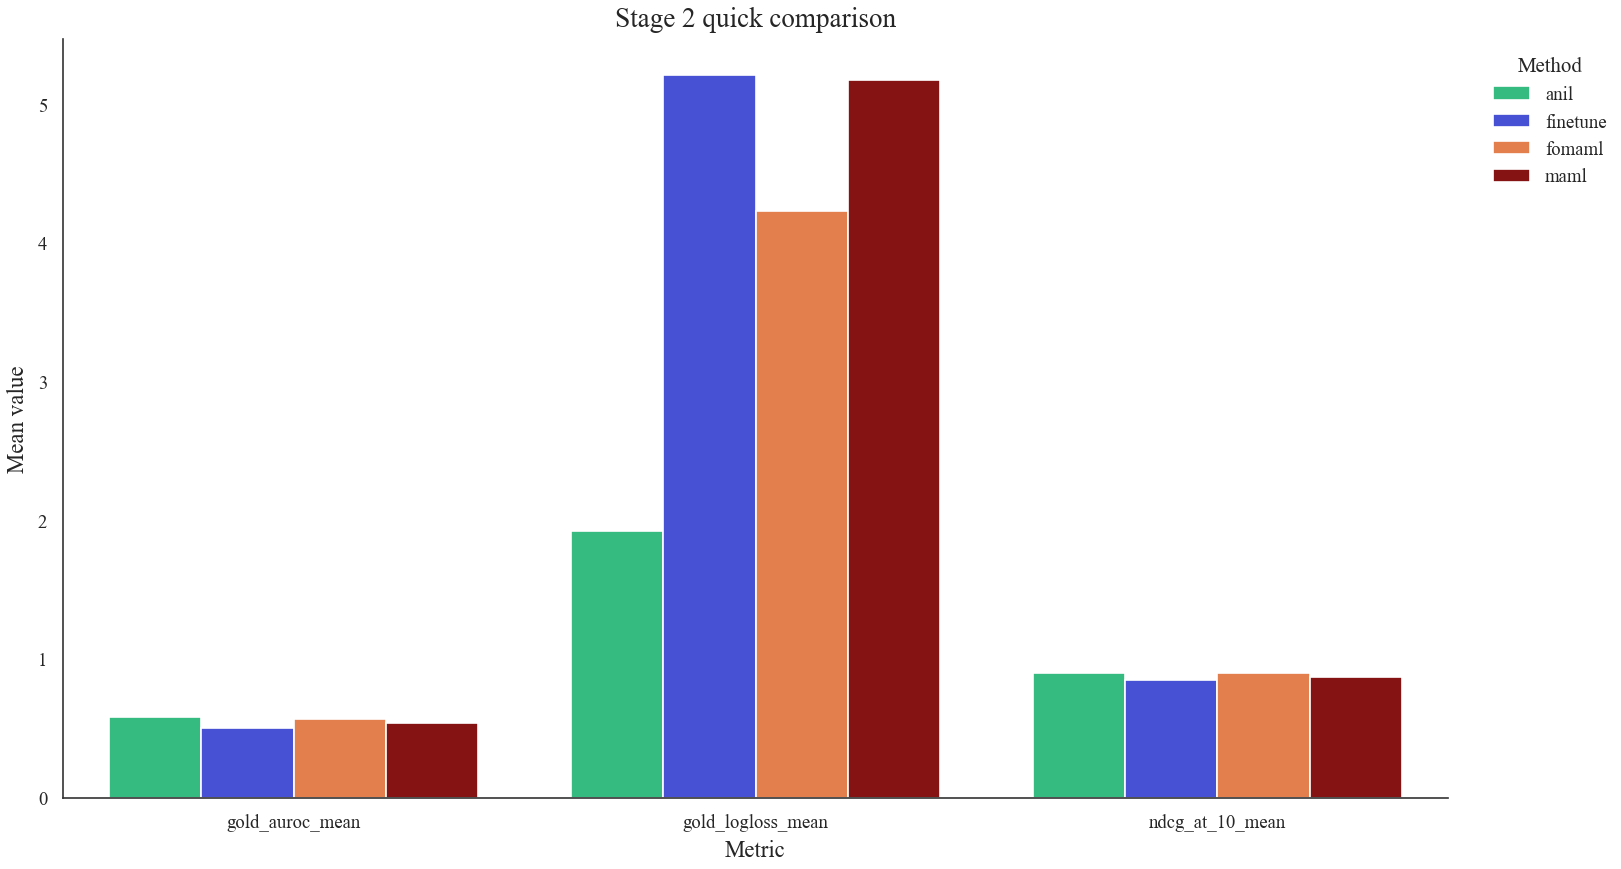

In [8]:
if not experiment_summary.empty:
    quick_df = experiment_summary.copy()
    if "target_department" in quick_df.columns:
        quick_df = quick_df[
            quick_df["target_department"] == first_config["task_config"]["target_department"]
        ].copy()

    metric_columns = [
        c for c in ["gold_auroc_mean", "gold_logloss_mean", "ndcg_at_10_mean"] if c in quick_df.columns
    ]
    if metric_columns and "method" in quick_df.columns:
        fig, ax = plot_stage2_metric_comparison(
            quick_df,
            metrics=metric_columns,
            group_col="method",
            title="Stage 2 quick comparison",
        )
    else:
        display(quick_df.head(20))
else:
    print("No saved experiment results are available yet.")


## Quick Summary Table

Compact result table for fast inspection. Full thesis-ready tables are in `17.1_stage2_analysis_dashboard.ipynb`.


In [9]:
if not experiment_summary.empty:
    _metric_cols = [c for c in experiment_summary.columns if c.endswith("_mean")]
    _key_cols = ["experiment_id", "method", "init_name", "n_support_pos", "n_support_neg",
                  "inner_steps", "target_department", "status", "n_metric_rows"]
    _display_cols = [c for c in _key_cols if c in experiment_summary.columns] + _metric_cols
    _display_cols = list(dict.fromkeys(_display_cols))  # deduplicate preserving order

    quick_summary = experiment_summary[_display_cols].copy()
    _sort_by = [c for c in ["method", "init_name", "n_support_pos", "inner_steps"] if c in quick_summary.columns]
    if _sort_by:
        quick_summary = quick_summary.sort_values(_sort_by).reset_index(drop=True)
    display(quick_summary)
else:
    print("Run experiments first to populate the summary.")


,experiment_id,method,init_name,n_support_pos,n_support_neg,inner_steps,target_department,status,n_metric_rows,gold_auroc_mean,...,n_positive_mean,precision_at_5_mean,recall_at_5_mean,ndcg_at_5_mean,precision_at_10_mean,recall_at_10_mean,ndcg_at_10_mean,precision_at_20_mean,recall_at_20_mean,ndcg_at_20_mean
0,stage2__init-A_weak_only__method-anil__kpos-2_...,anil,A_weak_only,2,2,5,Logistics,success,20,0.582733,...,7.65,0.80,0.552430,0.868107,0.727738,0.906623,0.898369,0.744766,1.0,0.950785
1,stage2__init-A_weak_only__method-anil__kpos-5_...,anil,A_weak_only,5,5,5,Logistics,success,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,stage2__init-A_weak_only__method-finetune__kpo...,finetune,A_weak_only,2,2,5,Logistics,success,20,0.500000,...,7.65,0.72,0.478025,0.758478,0.737738,0.912835,0.849515,0.744766,1.0,0.891858
3,stage2__init-A_weak_only__method-finetune__kpo...,finetune,A_weak_only,5,5,5,Logistics,no_target_episodes_available,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,stage2__init-A_weak_only__method-fomaml__kpos-...,fomaml,A_weak_only,2,2,5,Logistics,success,20,0.563815,...,7.65,0.79,0.539968,0.845775,0.737738,0.920909,0.896894,0.744766,1.0,0.941844
5,stage2__init-A_weak_only__method-fomaml__kpos-...,fomaml,A_weak_only,5,5,5,Logistics,success,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,stage2__init-A_weak_only__method-maml__kpos-2_...,maml,A_weak_only,2,2,5,Logistics,success,20,0.535714,...,7.65,0.81,0.549811,0.810492,0.752738,0.931169,0.866941,0.744766,1.0,0.912426
7,stage2__init-A_weak_only__method-maml__kpos-5_...,maml,A_weak_only,5,5,5,Logistics,success,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Artifact Verification

Check which expected artifacts are present for each resolved experiment.


In [10]:
artifact_names = ["resolved_config.yaml", "metrics.csv", "predictions.csv",
                   "history.csv", "stage2_result_summary.json"]

artifact_rows = []
for exp_id, _ in experiment_list:
    exp_dir = EXPERIMENT_ROOT / exp_id
    row = {"experiment_id": exp_id}
    for name in artifact_names:
        row[name] = (exp_dir / name).exists()
    artifact_rows.append(row)

artifact_df = pd.DataFrame(artifact_rows)
display(artifact_df)


,experiment_id,resolved_config.yaml,metrics.csv,predictions.csv,history.csv,stage2_result_summary.json
0,stage2__init-A_weak_only__method-finetune__kpo...,True,False,False,False,True
1,stage2__init-A_weak_only__method-anil__kpos-5_...,True,True,True,True,True
2,stage2__init-A_weak_only__method-fomaml__kpos-...,True,True,True,True,True
3,stage2__init-A_weak_only__method-maml__kpos-5_...,True,True,True,True,True
